<a href="https://colab.research.google.com/github/Laere11/Laere11/blob/Batteries/Ford_Focus_032725.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Full Charge Condition 03/27/25, last balance was on 03/12/25.

Detailed Cell Data:
    cell  voltage  board  mV_from_avg   z_score
0      1   4.0655      0          2.4  0.288829
1      2   4.0625      0         -0.6 -0.072207
2      3   4.0643      0          1.2  0.144414
3      4   4.0605      0         -2.6 -0.312898
4      5   4.0619      0         -1.2 -0.144414
..   ...      ...    ...          ...       ...
81    82   4.0658      6          2.7  0.324933
82    83   4.0655      7          2.4  0.288829
83    84   4.0631      7          0.0  0.000000
84    85   4.0633      7          0.2  0.024069
85    86   4.0633      7          0.2  0.024069

[86 rows x 5 columns]


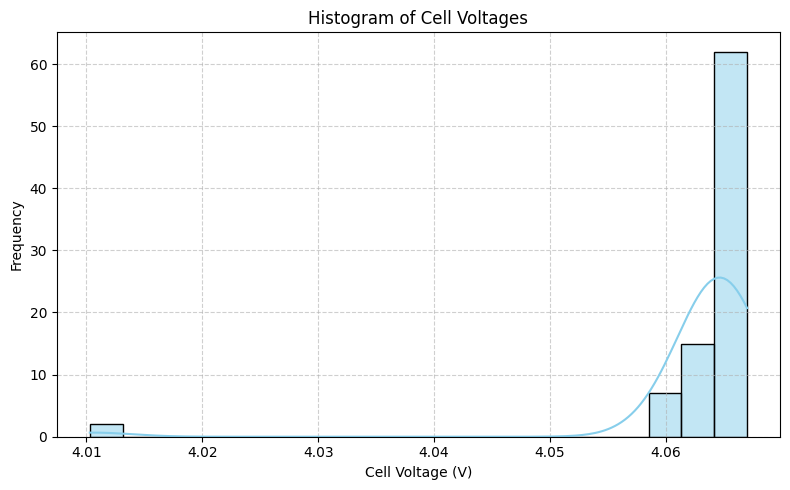

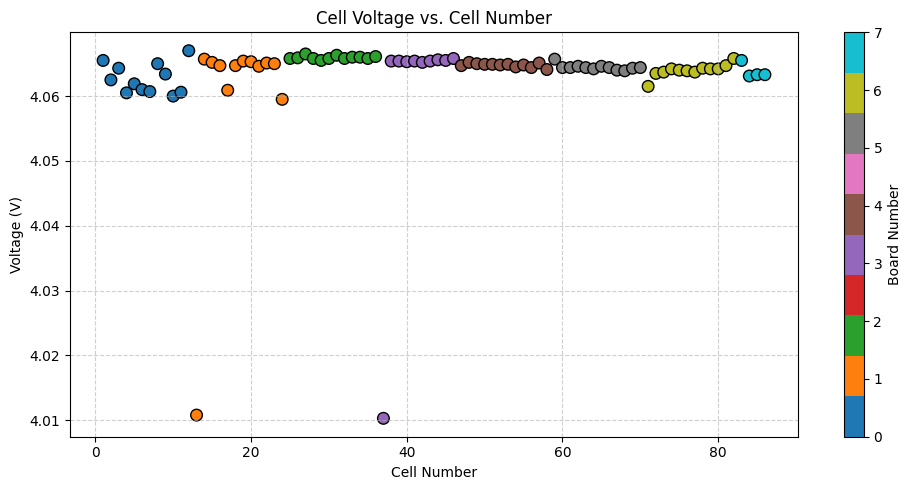

<ipython-input-1-f77ab642b3b1>:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='board', y='voltage', data=df, palette="pastel")


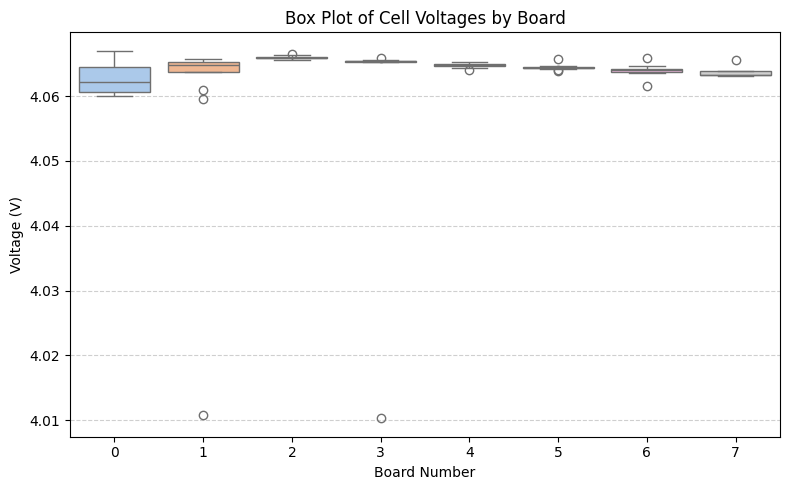

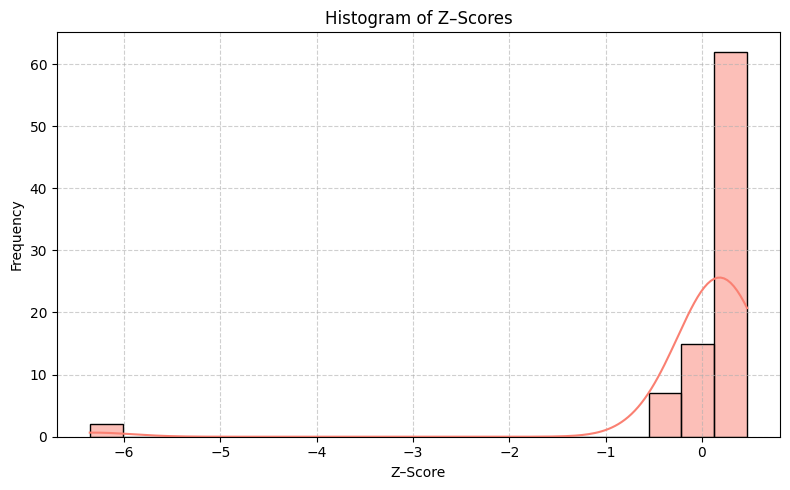

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# Data Setup
# ---------------------------
# Define voltages board by board
board0 = [4.0655, 4.0625, 4.0643, 4.0605, 4.0619, 4.0610, 4.0607, 4.0650, 4.0634, 4.0600, 4.0606, 4.0670]
board1 = [4.0108, 4.0657, 4.0652, 4.0647, 4.0609, 4.0647, 4.0654, 4.0653, 4.0646, 4.0651, 4.0650, 4.0595]
board2 = [4.0658, 4.0659, 4.0665, 4.0658, 4.0655, 4.0658, 4.0663, 4.0658, 4.0660, 4.0660, 4.0658, 4.0661]
board3 = [4.0103, 4.0654, 4.0654, 4.0653, 4.0654, 4.0652, 4.0654, 4.0656, 4.0655, 4.0658]
board4 = [4.0647, 4.0652, 4.0650, 4.0649, 4.0649, 4.0648, 4.0649, 4.0645, 4.0648, 4.0644, 4.0651, 4.0641]
board5 = [4.0657, 4.0644, 4.0644, 4.0646, 4.0644, 4.0642, 4.0646, 4.0644, 4.0640, 4.0639, 4.0643, 4.0644]
board6 = [4.0615, 4.0635, 4.0637, 4.0642, 4.0640, 4.0639, 4.0637, 4.0643, 4.0642, 4.0642, 4.0647, 4.0658]
board7 = [4.0655, 4.0631, 4.0633, 4.0633]

# Concatenate all boards
voltages = board0 + board1 + board2 + board3 + board4 + board5 + board6 + board7

# Create board labels accordingly
boards = (
    [0]*len(board0) +
    [1]*len(board1) +
    [2]*len(board2) +
    [3]*len(board3) +
    [4]*len(board4) +
    [5]*len(board5) +
    [6]*len(board6) +
    [7]*len(board7)
)

# Create sequential cell numbers (1-indexed)
cells = list(range(1, len(voltages) + 1))

# Given overall average voltage (avgV) from the header
avgV = 4.0631

# ---------------------------
# Create DataFrame & Compute Metrics
# ---------------------------
df = pd.DataFrame({
    'cell': cells,
    'voltage': voltages,
    'board': boards
})

# Compute overall standard deviation from the data
sigma = df['voltage'].std()

# Compute the difference from average in mV and Z–score
df['mV_from_avg'] = (df['voltage'] - avgV) * 1000  # in millivolts
df['z_score'] = (df['voltage'] - avgV) / sigma

# Print the detailed cell data
print("Detailed Cell Data:")
print(df)

# ---------------------------
# Plot 1: Histogram of Cell Voltages
# ---------------------------
plt.figure(figsize=(8, 5))
sns.histplot(df['voltage'], bins=20, kde=True, color='skyblue')
plt.xlabel("Cell Voltage (V)")
plt.ylabel("Frequency")
plt.title("Histogram of Cell Voltages")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ---------------------------
# Plot 2: Scatter Plot - Cell Voltage vs. Cell Number
# ---------------------------
plt.figure(figsize=(10, 5))
scatter = plt.scatter(df['cell'], df['voltage'], c=df['board'], cmap="tab10", s=70, edgecolor='k')
plt.xlabel("Cell Number")
plt.ylabel("Voltage (V)")
plt.title("Cell Voltage vs. Cell Number")
plt.colorbar(scatter, label="Board Number")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ---------------------------
# Plot 3: Box Plot by Board
# ---------------------------
plt.figure(figsize=(8, 5))
sns.boxplot(x='board', y='voltage', data=df, palette="pastel")
plt.xlabel("Board Number")
plt.ylabel("Voltage (V)")
plt.title("Box Plot of Cell Voltages by Board")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ---------------------------
# Plot 4: Histogram of Z–Scores
# ---------------------------
plt.figure(figsize=(8, 5))
sns.histplot(df['z_score'], bins=20, kde=True, color='salmon')
plt.xlabel("Z–Score")
plt.ylabel("Frequency")
plt.title("Histogram of Z–Scores")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
